# HDT 3: Inferencia, Naive Bayes y Regresión

**Ciencia de Datos, Sección A** · Asignada: jueves 20 de agosto · **Entrega: jueves 27 de agosto, 23:59**

**Nombre:** Milton Beltran

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la mini-bitácora del final.

## Setup

Dependencias: `pip install numpy pandas matplotlib seaborn scikit-learn`. Todo es determinista (semillas fijas y datasets estáticos): las verificaciones son exactas.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

## Parte A · Inferencia y A/B testing (0.5 pt)

El experimento del botón, en grande: 50,000 visitantes por grupo. La tasa real del control es 10.0% y la de la variante 10.5%: un efecto **pequeño** con una muestra **enorme**. Ese contraste es el tema de la parte D.

### Ejercicio 1 (0.15): la diferencia y su intervalo

(a) La diferencia observada `obs` entre variante y control. (b) El error estándar de la diferencia: $\sqrt{s_a^2/n + s_b^2/n}$ con `var(ddof=1)`. (c) El intervalo del 95%: `obs` ± 1.96 × SE. ¿El intervalo incluye el cero?

In [2]:
rng = np.random.default_rng(9)
n_ab = 50_000
control = rng.binomial(1, 0.100, n_ab)
variante = rng.binomial(1, 0.105, n_ab)

obs = variante.mean() - control.mean()
se = np.sqrt(control.var(ddof=1) / n_ab + variante.var(ddof=1) / n_ab)

ic_bajo, ic_alto = obs - 1.96 * se, obs + 1.96 * se

# imprimir el intervalo
print(f"Intervalo 95%: {ic_bajo:.5f} a {ic_alto:.5f}")

# Verificación (descomentar):
assert round(obs, 5) == 0.00506
assert round(obs - 1.96 * se, 5) == 0.00132

Intervalo 95%: 0.00132 a 0.00880


### Ejercicio 2 (0.20): test de permutación desde cero

Si el botón no importara, las etiquetas serían intercambiables. Completar la función: concatenar, revolver `reps` veces, partir en dos grupos del tamaño original, guardar la diferencia, y devolver la fracción de diferencias tan extremas como la observada.

In [3]:
def test_permutacion(a, b, reps=3000, seed=1):
    rng_p = np.random.default_rng(seed)
    obs_ = b.mean() - a.mean()

    # 1) juntar los dos grupos en una sola bolsa
    todos = np.concatenate([a, b])
    n = len(a)

    # 2) y 3) revolver reps veces y guardar la diferencia de cada particion
    difs = []
    for _ in range(reps):
        rng_p.shuffle(todos)  
        difs.append(todos[n:].mean() - todos[:n].mean())

    # 4) fraccion de diferencias tan extremas como la observada (dos colas)
    difs = np.array(difs)
    return (np.abs(difs) >= abs(obs_)).mean()

p_val = test_permutacion(control, variante)

print("p-value =", round(p_val, 4))

# Verificación (descomentar):
assert round(p_val, 3) == 0.008

p-value = 0.008


### Ejercicio 3 (0.15): 100 tests bajo $H_0$

Ningún efecto existe: los dos grupos vienen de la misma Normal. Contar cuántos "descubrimientos" aparecen con $\alpha = 0.05$ (umbral 1.96) y cuántos sobreviven Bonferroni ($\alpha/100$, umbral 3.48).

In [4]:
def z(a_, b_):
    s = np.sqrt(a_.var()/len(a_) + b_.var()/len(b_))
    return (b_.mean() - a_.mean()) / s

rng3 = np.random.default_rng(2)
significativos = 0
significativos_bonf = 0

for i in range(100):
    g1 = rng3.normal(0, 1, 500)
    g2 = rng3.normal(0, 1, 500)   # exactamente la misma distribución
    # ¿Qué va aquí? contar |z| > 1.96 y |z| > 3.48
    z_i = z(g1, g2)

    if abs(z_i) > 1.96:
        significativos += 1
    if abs(z_i) > 3.48:
        significativos_bonf += 1

print("Descubrimientos con alfa =  0.05:", significativos)
print("Sobreviven a Bonferroni:", significativos_bonf)

# Verificación (descomentar):
# assert significativos == 3 and significativos_bonf == 0

Descubrimientos con alfa =  0.05: 3
Sobreviven a Bonferroni: 0


## Parte B · Naive Bayes (0.5 pt)

Un filtro de spam para mensajes de texto, desde cero, como en la sesión 7. El corpus:

In [5]:
textos = [
    "gana un premio reclamalo hoy mismo",
    "oferta exclusiva solo por hoy haz clic",
    "felicidades fuiste seleccionado para un premio",
    "crédito preaprobado sin requisitos aplica ya",
    "última oportunidad descuento del 90 por ciento",
    "tu cuenta será suspendida verifica tus datos",
    "recarga doble gratis si respondes ya",
    "has ganado un viaje reclama tu premio aquí",
    "nos vemos a las 8 en la u",
    "ya voy en camino llego en 10",
    "mamá dice que compres tortillas",
    "el partido quedó 2 a 1 increíble",
    "te mando el resumen de la clase en la noche",
    "feliz cumple nos vemos el sábado",
    "se me olvidó la usb me la prestas",
    "la tarea es para el martes no para hoy",
]

etiquetas = ["spam"] * 8 + ["normal"] * 8

test_x = [
    "reclama tu premio gratis haz clic ya",
    "llego en 5 nos vemos en la entrada",
    "oferta solo hoy tu crédito ya está aprobado",
    "la clase se movió para el jueves",
]
test_y = ["spam", "normal", "spam", "normal"]

print(len(textos), len(etiquetas), len(test_x))

16 16 4


### Ejercicio 4 (0.15): bolsa de palabras

(a) `vocab`: la lista **ordenada** de palabras únicas del corpus de entrenamiento. (b) `idx`: diccionario palabra → posición. (c) `conteos` (matriz clases × |V|) y `priors`, contando sobre `textos`.

In [6]:
def tokenizar(texto):
    return texto.lower().split()

clases = sorted(set(etiquetas))   # ["normal", "spam"]

# ¿Qué va aquí?
vocabulario = sorted({palabra for t in textos for palabra in tokenizar(t)})
idx = {palabra: i for i, palabra in enumerate(vocabulario)}

conteos = np.zeros((len(clases), len(vocabulario)))
priors = np.zeros(len(clases))

for texto, etiqueta in zip(textos, etiquetas):
    clase_idx = clases.index(etiqueta)
    priors[clase_idx] += 1
    for palabra in tokenizar(texto):
        palabra_idx = idx[palabra]
        conteos[clase_idx, palabra_idx] += 1

print("Palabras únicas:", len(vocabulario))
print("Documentos por clase:", priors)
print("Matriz de conteos", conteos.shape, "...Tokens por clase:", conteos.sum(axis=1))


# Verificación (descomentar):
assert len(vocabulario) == 86
assert conteos.shape == (2, 86)
assert priors.tolist() == [8.0, 8.0]

Palabras únicas: 86
Documentos por clase: [8. 8.]
Matriz de conteos (2, 86) ...Tokens por clase: [60. 53.]


### Ejercicio 5 (0.20): entrenar con Laplace y clasificar

(a) Suavizar: `conteos + 1`. (b) `log_veros` (normalizar por fila y tomar log) y `log_prior`. (c) `puntajes(texto)` que suma log-prior más log-verosimilitud de cada palabra **conocida**, y `predecir(texto)` con el argmax. (d) Clasificar los 4 mensajes de prueba.

In [7]:
# ¿Qué va aquí?
suavizados = conteos + 1
log_veros = np.log(suavizados / suavizados.sum(axis=1, keepdims=True))
log_priors = np.log(priors / priors.sum())

# def puntajes(texto):
def puntajes(texto):
    p = log_priors.copy()
    for palabra in tokenizar(texto):
        if palabra in idx:
            p += log_veros[:, idx[palabra]]
    return p

# def predecir(texto):
def predecir(texto):
    return clases[np.argmax(puntajes(texto))]

for texto in test_x:
    print(predecir(texto), "|", texto)
# Verificación (descomentar):
assert [predecir(t) for t in test_x] == test_y

spam | reclama tu premio gratis haz clic ya
normal | llego en 5 nos vemos en la entrada
spam | oferta solo hoy tu crédito ya está aprobado
normal | la clase se movió para el jueves


### Ejercicio 6 (0.15): las palabras que delatan al spam

`ratio` = log-verosimilitud de spam menos la de normal. Con `np.argsort`, extraer las 5 palabras más spam (`informativas_spam`) y las 5 más normales (`informativas_normal`).

In [8]:
# ¿Qué va aquí?
# Pista: inv = {i: w for w, i in idx.items()}
ratio = log_veros[1] - log_veros[0]
inv = {i: w for w, i in idx.items()}

informativas_spam = [inv[i] for i in np.argsort(-ratio)[:5]]
informativas_normal = [inv[i] for i in np.argsort(ratio)[:5]]

print("Mas Spam:", informativas_spam)
print("Mas Normal:", informativas_normal)

# Verificación (descomentar):
assert informativas_spam[0] == "premio"

Mas Spam: ['premio', 'un', 'tu', 'por', 'crédito']
Mas Normal: ['la', 'en', 'el', 'a', 'me']


## Parte C · Regresión lineal (0.8 pt)

`diamonds`: 53,940 diamantes reales. La pregunta de negocio: ¿cuánto vale un quilate?

### Ejercicio 7 (0.20): EDA mínimo

(a) `shape` y `dtypes`. (b) Media y mediana de `price`: ¿cuál es mayor y qué dice eso de la cola? (c) El histograma de `price`.

(53940, 10)
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object
Media: 3932.8 | Mediana: 2401.0
La media es mayor que la mediana, entonces la cola larga esta a la derecha


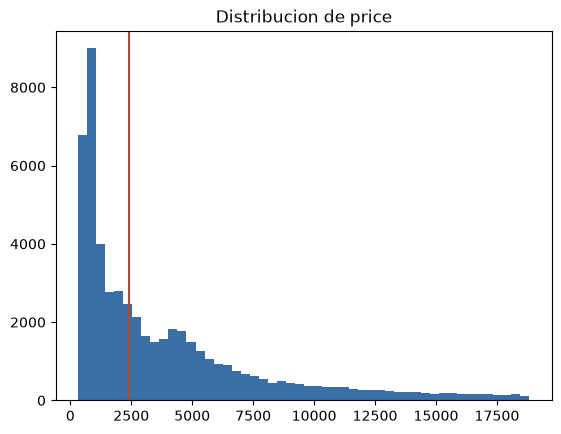

In [9]:
diamonds = sns.load_dataset("diamonds")

# ¿Qué va aquí?
print(diamonds.shape)
print(diamonds.dtypes)

media = diamonds["price"].mean()
mediana = diamonds["price"].median()

print("Media:", round(media, 2), "| Mediana:", mediana)
print("La media es mayor que la mediana, entonces la cola larga esta a la derecha")

plt.hist(diamonds["price"], bins=50, color=AZUL)
plt.axvline(mediana, color=ROJO)
plt.title("Distribucion de price")
plt.show()

# Verificación (descomentar):
assert diamonds.shape == (53940, 10)
assert diamonds["price"].median() == 2401.0

### Ejercicio 8 (0.20): OLS a mano

`price ~ carat` con las ecuaciones normales: (a) `Xb` con columna de unos y `np.linalg.solve`. (b) $R^2$ a mano (`r2_precio`). (c) Comparar contra `LinearRegression`.

In [10]:
from sklearn.linear_model import LinearRegression

x_c = diamonds["carat"].to_numpy(float)
y_p = diamonds["price"].to_numpy(float)

# ¿Qué va aquí?
Xb = np.column_stack([np.ones(len(x_c)), x_c])
beta = np.linalg.solve(Xb.T @ Xb, Xb.T @ y_p)

pred = Xb @ beta
residuos = y_p - pred

r2_precio = 1 - (residuos ** 2).sum() / ((y_p - y_p.mean()) ** 2).sum()

modelo = LinearRegression().fit(x_c.reshape(-1, 1), y_p)

print("A mano :", round(beta[0], 2), round(beta[1], 2), "| R2:", round(r2_precio, 3))
print("sklearn:", round(modelo.intercept_, 2), round(modelo.coef_[0], 2), "| R2:", round(modelo.score(x_c.reshape(-1, 1), y_p), 3))

# Verificación (descomentar):
assert round(r2_precio, 3) == 0.849

A mano : -2256.36 7756.43 | R2: 0.849
sklearn: -2256.36 7756.43 | R2: 0.849


### Ejercicio 9 (0.20): los residuos delatan, el log arregla

(a) Graficar residuos vs predicción del modelo del ejercicio 8. (b) Ajustar `log(price) ~ log(carat)` (`r2_log`) y graficar sus residuos. (c) Comparar los dos $R^2$ y las dos nubes.

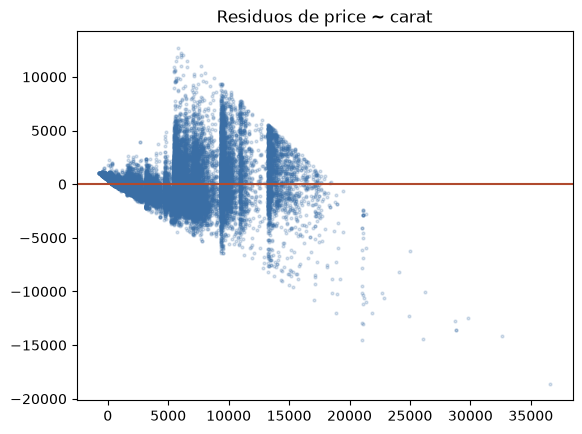

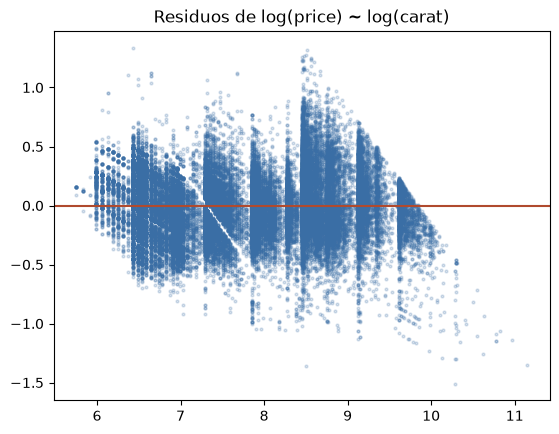

R2 de price ~ carat: 0.849 | R2 de log(price) ~ log(carat): 0.933
En la escala normal los residuos se abren como embudo, en la escala log la nube queda pareja


In [11]:
# ¿Qué va aquí?
# Pista: np.log para ambas variables; el patrón del gráfico
# de residuos está en el notebook de la sesión 8.5
plt.scatter(pred, residuos, s=4, alpha=0.2, color=AZUL)
plt.axhline(0, color=ROJO)
plt.title("Residuos de price ~ carat")
plt.show()

log_x = np.log(x_c)
log_y = np.log(y_p)

Xb = np.column_stack([np.ones(len(log_x)), log_x])
beta = np.linalg.solve(Xb.T @ Xb, Xb.T @ log_y)

pred = Xb @ beta
residuos = log_y - pred

r2_log = 1 - (residuos ** 2).sum() / ((log_y - log_y.mean()) ** 2).sum()

plt.scatter(pred, residuos, s=4, alpha=0.2, color=AZUL)
plt.axhline(0, color=ROJO)
plt.title("Residuos de log(price) ~ log(carat)")
plt.show()

print("R2 de price ~ carat:", round(r2_precio, 3), "| R2 de log(price) ~ log(carat):", round(r2_log, 3))
print("En la escala normal los residuos se abren como embudo, en la escala log la nube queda pareja")

# Verificación (descomentar):
assert round(r2_log, 3) == 0.933

### Ejercicio 10 (0.20): ¿y si agregamos más features?

Regresión múltiple en la escala log: `log(price) ~ log(carat) + depth + table`. Calcular `r2_multi` y responder en un comentario: ¿cuánto mejoró respecto al ejercicio 9?

In [12]:
# ¿Qué va aquí?
Xb = np.column_stack([np.ones(len(log_x)), log_x, diamonds["depth"], diamonds["table"]])
beta = np.linalg.solve(Xb.T @ Xb, Xb.T @ log_y)

pred = Xb @ beta
residuos = log_y - pred

r2_multi = 1 - (residuos ** 2).sum() / ((log_y - log_y.mean()) ** 2).sum()

print("R2 con log(carat):", round(r2_log, 3), "| R2 agregando depth y table:", round(r2_multi, 3))
print("Mejora:", round(r2_multi - r2_log, 4))


# Verificación (descomentar):
assert round(r2_multi, 3) == 0.935

R2 con log(carat): 0.933 | R2 agregando depth y table: 0.935
Mejora: 0.0023


## Parte D · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

Dos preguntas, 2-3 líneas cada una, **citando los números obtenidos**:

**(a)** El ejercicio 2 dio p = 0.008: el efecto del botón es estadísticamente real. El lift observado fue de medio punto porcentual (10.4% vs 9.9%). ¿Basta eso para lanzar el botón a producción? ¿Qué información falta para decidir?

**(b)** El modelo log-log del ejercicio 9 se ajustó con diamantes de hasta 5 quilates. ¿Por qué no es confiable usarlo para tasar un diamante de 8 quilates, aunque la fórmula produzca un número?

_(Responder editando esta celda)_

**Respuesta (a):** No basta: el intervalo del ejercicio 1 va de 0.00132 a 0.00880, así que ni el mejor escenario llega a un punto porcentual y con un efecto tan pequeño la decisión la define el costo, no el p-value. Falta cuánto ingreso deja una conversión extra contra lo que cuesta implementar el botón, y cuántos tests se corrieron antes de este: en el ejercicio 3 salieron 3 "descubrimientos" de 100 sobre datos sin ningún efecto.

**Respuesta (b):** Porque 8 quilates queda fuera del rango de ajuste: el máximo del dataset es 5.01 y solo 5 piedras pasan de 4 quilates, así que la pendiente de 1.676 se estimó con diamantes pequeños. El modelo ya falla en su propio borde (predice 69,503 para el de 5.01 quilates, que cuesta 18,018) y para 8 quilates da 152,272, ocho veces el diamante más caro de los datos. El R² de 0.933 solo mide el ajuste adentro del rango observado.

## Mini-bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- **Ejercicio 1:** `SyntaxError` por dos backticks pegados al `print`. Aparte pregunté si servía `p*(1-p)/n` en vez de `var(ddof=1)`: entendí que en datos 0/1 la varianza **es** p(1-p), así que dan el mismo número.

- **Ejercicio 2:** `rng_p.shuffle()` revuelve en el lugar y devuelve `None`, por eso no se asigna a nada. El `abs` de la comparación final es lo que lo hace de dos colas; sin él el p-value se parte a la mitad.

- **Ejercicio 3:** Pregunté si los contadores iban con `elif`. No: los que pasan 3.48 ya pasaron 1.96, son conjuntos anidados y no casos excluyentes.

- **Ejercicio 4:** El vocabulario salió con 113 palabras en vez de 86 por escribir el comprehension con paréntesis (generador) en vez de llaves (set). Entendí que el bug es silencioso porque `sorted()` acepta cualquier iterable.

- **Ejercicio 5:** `keepdims=True` deja la suma en forma (2,1) para poder dividir fila por fila; sin él, (2,86) entre (2,) no se difunde. Y hay que copiar `log_priors` porque los arrays son referencias y el `+=` modificaría el original.

- **Ejercicio 6:** El assert falló dos veces, primero por `[-5:]` y luego por `[5:]`. Entendí que para ordenar descendente hay que negar el array (`argsort(-x)[:5]`) y no voltear con `[::-1]`, porque el volteo invierte también los empates y `premio` y `un` tienen el mismo ratio.

- **Ejercicio 9:** El log convierte el error proporcional (el embudo de los residuos) en error constante, que es el supuesto de la regresión lineal. De ahí el salto de 0.849 a 0.933.